## Group 5 | Assignment 1 | Road checker: Assessing Bicycle Lane Quality Using Smartphone Sensor Data

Group members
- Su Acar (2475901)
- Vikram Chandrasekaran (2542544)
- Henrique DaSilva Couto (2463334)

## Dataset extraction and pre-checks

Downloads the raw sensor data folder from Google Drive into `downloads/` (installing `gdown` if needed). Skip re-running this cell if the data is already present locally.

In [26]:
#Extract data from Google Drive ONLY IF it is not in the data/ folder yet
# Download gdown-6.2.0

try:
    
    import gdown
    import zipfile
    import shutil
except ImportError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "gdown", "zipfile", "shutil"])
    import gdown

folder_url = "https://drive.google.com/drive/folders/1DpgvoIUkZJ55P85hu4zdvwaJ9wdvKUn8"
output_dir = "downloads/"

gdown.download_folder(
    url=folder_url,
    output=output_dir,
    quiet=False,
    use_cookies=False
)

shutil.move("./downloads/road-checker-data/", "./data/downloads/",)

import os
os.rmdir("./downloads/")

Retrieving folder contents


Processing file 1STx4KSDMpBQG9c3vFepD7ptN_WxPadCb HC-annotations-19min-2026-09-19_09-02-09.zip
Processing file 1dedsRtbjrC08VoKBfL3tzH3Qiz0Qe_ZQ HC-annotations-19min-2026-09-19_10-44-41.zip
Processing file 1VoPjmYsZjDH0ZHblIgNGz6dCDtDko76P HC-bumpy-2min-2026-09-19_08-54-37.zip
Processing file 1BmuNQSm5XJqa2u8SONxFBIlusN17dCYs Raw001_Smooth.zip
Processing file 1LwAA1_tM7cu86V67fnOpAoZKqd9XEIK_ Raw002_Smooth.zip
Processing file 1DR5dgrvtVgNP1pgypWaGbuJesFwX8pRg Raw003_Smooth.zip
Processing file 1zUpRJBDDcfZtXXNhkNio93RWI5RQthBn Raw004_Bumpy.zip
Processing file 1o5Xv3ty8Nm1a2pqGt04Srxo6mVzzveji Raw005_Bumpy.zip
Processing file 181pGS5JSw2CyzuaaKngpdsrrgk_vEMoR Raw006_Bumpy.zip
Processing file 1g8PrFEYCTKI-olneZjBxgRXkO_BmDcfY Raw007_Smooth.zip
Processing file 1FkoZFyMlittvcMbLZObdbryoUSjbt9H- Raw008_Smooth.zip
Processing file 1ATJNFdbcKLB6GWh7VZjEa2_RG4-4Q5kF Raw009_Smooth.zip
Processing file 10gi219MerRfki0ZR6XnTbIbufKMmhnpp Raw010_Bumpy.zip
Processing file 1d_JSkdOqnkTdgDGyI5lIDKYNNr3n0

Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1STx4KSDMpBQG9c3vFepD7ptN_WxPadCb
To: /Users/vikramchandrasekaran/Documents/TUEindhoven/DataAnalysisAndLearningMethods/Assignment1/road-checker/downloads/road-checker-data/HC-annotations-19min-2026-09-19_09-02-09.zip
100%|██████████| 25.2M/25.2M [00:01<00:00, 19.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1dedsRtbjrC08VoKBfL3tzH3Qiz0Qe_ZQ
To: /Users/vikramchandrasekaran/Documents/TUEindhoven/DataAnalysisAndLearningMethods/Assignment1/road-checker/downloads/road-checker-data/HC-annotations-19min-2026-09-19_10-44-41.zip
100%|██████████| 24.9M/24.9M [00:01<00:00, 15.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=1VoPjmYsZjDH0ZHblIgNGz6dCDtDko76P
To: /Users/vikramchandrasekaran/Documents/TUEindhoven/DataAnalysisAndLearningMethods/Assignment1/road-checker/downloads/road-checker-data/HC-bumpy-2min-2026-09-19_08

## Calculating frequencies of all data - sensor wise

### Unzip all recordings

In [28]:
import glob
import zipfile
zip_files = glob.glob("data/downloads/Raw*.zip")

for file_path in zip_files:
    with zipfile.ZipFile(file_path, 'r') as zip_ref:
        folder_name = (zip_ref.filename).split('/')[-1][:-4]
        zip_ref.extractall(f'data/extracted/{folder_name}')

### Sampling frequency per sensor across recordings

For each recording, the sampling frequency (Hz) of each sensor is estimated from the mean interval between consecutive `seconds_elapsed` timestamps

The plots below show for each sensor how its sampling frequency varies across recordings (sorted alphabetically by recording name)

This is useful for spotting recordings with inconsistencies and find out which device is causing these

In [34]:
import numpy as np
import pandas as pd
import json

base_path_extracted = "data/extracted"
data_file_mapping = {
    "accelerometer_calibrated" : "Accelerometer.csv",
    "accelerometer_uncalibrated" : "AccelerometerUncalibrated.csv",
    "gravity" : "Gravity.csv",
    "gyroscope_calibrated": "Gyroscope.csv",
    "gyroscope_uncalibrated": "GyroscopeUncalibrated.csv"  
}

csv_files = glob.glob("data/extracted/*/*.csv")

recording_sensor_freq_mapping = {}

for file_path in csv_files: 
    recording_name = file_path.split('/')[-2] + ''
    recording_sensor_freq_mapping[recording_name] = {}
    for sensor, file_name in data_file_mapping.items():
        try:
            sensor_seconds_elapsed_array = pd.read_csv(f"{base_path_extracted }/{recording_name}/{file_name}")['seconds_elapsed']
            dt = sensor_seconds_elapsed_array.diff().mean()
            sensor_sampling_frequency_hz = 1 / dt
            recording_sensor_freq_mapping[recording_name][sensor] = sensor_sampling_frequency_hz
        except FileNotFoundError as e:
            continue

print("Values are in Hz")
print(json.dumps(recording_sensor_freq_mapping, indent = 4, default = str))

Values are in Hz
{
    "Raw012_Bumpy": {
        "accelerometer_calibrated": 62.20033510900654,
        "accelerometer_uncalibrated": 61.735166705419935,
        "gravity": 62.0335142868751,
        "gyroscope_calibrated": 62.152672016968985,
        "gyroscope_uncalibrated": 62.11684514315761
    },
    "Raw010_Bumpy": {
        "accelerometer_calibrated": 99.59786331054303,
        "accelerometer_uncalibrated": 99.59786331054305,
        "gravity": 99.59786331054303,
        "gyroscope_calibrated": 99.59786331054303,
        "gyroscope_uncalibrated": 99.59678442049855
    },
    "Raw030_Bumpy": {
        "accelerometer_calibrated": 62.2394746187573,
        "accelerometer_uncalibrated": 62.02203844425157,
        "gravity": 62.14294189348587,
        "gyroscope_calibrated": 62.27560354845678,
        "gyroscope_uncalibrated": 62.14275085850664
    },
    "Raw016_Bumpy": {
        "accelerometer_calibrated": 99.59503590582362,
        "accelerometer_uncalibrated": 99.59503697556153,
 

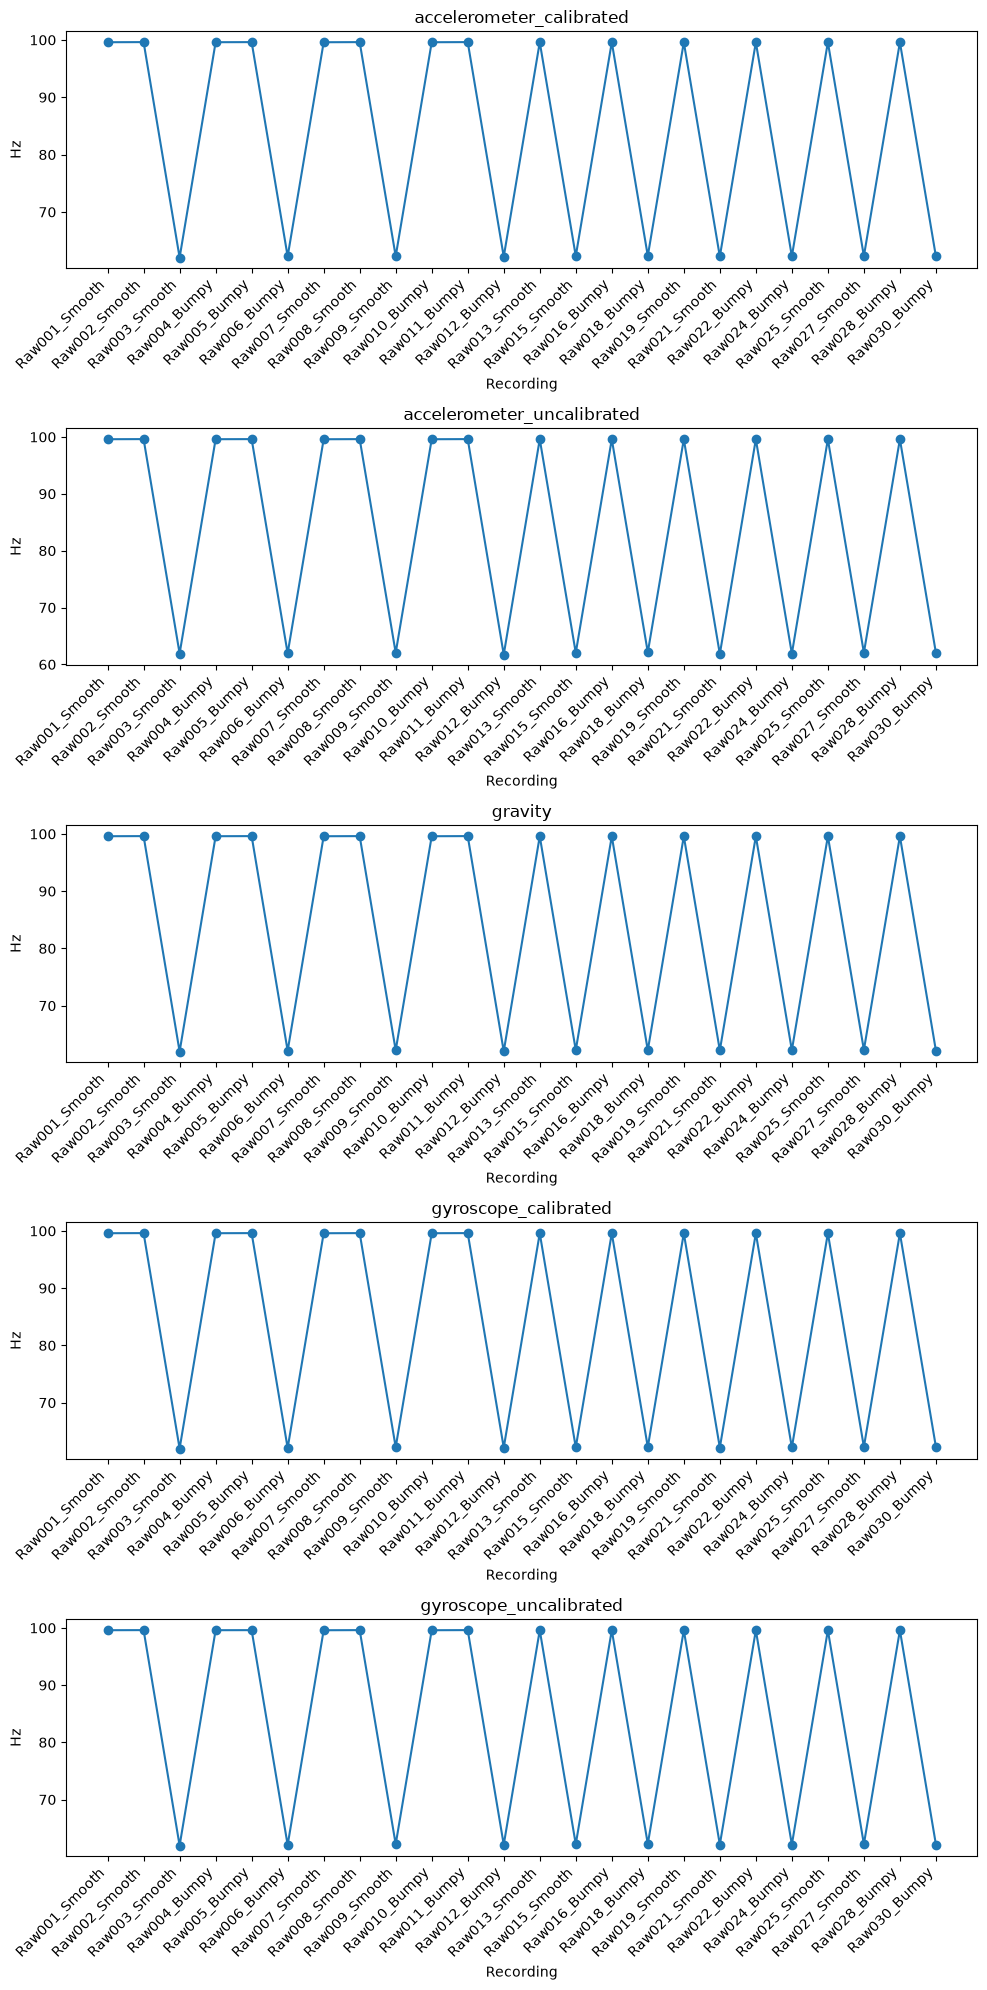

In [35]:
import matplotlib.pyplot as plt

freq_df = pd.DataFrame(recording_sensor_freq_mapping).T.sort_index()

sensors = freq_df.columns
fig, axes = plt.subplots(len(sensors), 1, figsize=(10, 4 * len(sensors)))

for ax, sensor in zip(axes, sensors):
    ax.plot(freq_df.index, freq_df[sensor], marker='o')
    ax.set_ylabel("Hz")
    ax.set_title(sensor)
    ax.set_xlabel("Recording")
    ax.tick_params(axis='x', rotation=45)
    for label in ax.get_xticklabels():
        label.set_ha('right')

plt.tight_layout()
plt.show()